# Atividade 4 - Parte 2

Este notebook contém as soluções da Parte 2. Cada item começa com as figuras dos slides de comando e termina com análise de resultados e conclusão em célula de texto.

In [1]:

import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

def find_project_file(relative_path):
    here = Path.cwd().resolve()
    candidates = [here / relative_path]
    candidates += [parent / relative_path for parent in here.parents]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Arquivo não encontrado: {relative_path}. Execute o notebook na raiz do repositório ou ajuste o caminho.')

def plot_loss(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.title(title)
    plt.xlabel('época / iteração')
    plt.ylabel('loss')
    plt.grid(True, alpha=0.3)
    plt.show()

def sigmoid_np(z):
    return 1 / (1 + np.exp(-z))

def softmax_np(z):
    z = np.asarray(z, dtype=float)
    z = z - np.max(z, axis=-1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=-1, keepdims=True)


## A2 - Treinamento no PyTorch

### Slides do comando do problema

<p><img src="../slides_comando/slide_36.png" width="900"></p>
<p><img src="../slides_comando/slide_37.png" width="900"></p>


In [ ]:

# A2 - Treinamento de uma rede ReLU no PyTorch para dados de dosagem x efeito
x_a2 = torch.linspace(0, 1, 31).reshape(-1, 1)
y_a2 = torch.exp(-((x_a2 - 0.5) ** 2) / 0.02)
y_a2 = y_a2 / y_a2.max()

class ReLUDoseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 2)
        self.out = nn.Linear(2, 1)
    def forward(self, x):
        h = F.relu(self.hidden(x))
        return self.out(h)

model_a2 = ReLUDoseNet()
opt_a2 = torch.optim.Adam(model_a2.parameters(), lr=0.03)
hist_a2 = []
for epoch in range(600):
    opt_a2.zero_grad()
    pred = model_a2(x_a2)
    loss = F.mse_loss(pred, y_a2)
    loss.backward()
    opt_a2.step()
    hist_a2.append(float(loss.detach()))

with torch.no_grad():
    vals = torch.tensor([[0.0], [0.5], [1.0]])
    outs = model_a2(vals).numpy().ravel()
print('Saída para três valores após treinamento:')
for v, o in zip(vals.numpy().ravel(), outs):
    print(f'dosagem={v:.2f} -> saída={o:.4f}')
print('\nParâmetros aprendidos:')
for name, p in model_a2.named_parameters():
    print(name, p.detach().numpy().round(4))
plot_loss(hist_a2, 'A2 - treinamento da rede ReLU')

# Simulação manual da rede treinada com os parâmetros do PyTorch
with torch.no_grad():
    W_hidden = model_a2.hidden.weight.detach().numpy()
    b_hidden = model_a2.hidden.bias.detach().numpy()
    W_out = model_a2.out.weight.detach().numpy()
    b_out = model_a2.out.bias.detach().numpy()

def relu_np(z):
    return np.maximum(0, z)
manual = relu_np(vals.numpy() @ W_hidden.T + b_hidden) @ W_out.T + b_out
print('\nComparação PyTorch x simulação manual:')
print(np.c_[outs, manual.ravel()])

plt.figure(figsize=(7,5))
plt.scatter(x_a2.numpy(), y_a2.numpy(), label='dados')
with torch.no_grad():
    plt.plot(x_a2.numpy(), model_a2(x_a2).numpy(), label='rede ReLU treinada')
plt.title('A2 - aproximação por rede ReLU')
plt.xlabel('dosagem')
plt.ylabel('efeito')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Análise dos resultados - A2

A rede ReLU tenta aproximar uma relação não linear entre dosagem e efeito. O treinamento em PyTorch ajusta pesos e bias para que a saída seja baixa nos extremos e maior na região central. A exigência de mostrar a saída para três valores é útil porque testa justamente os pontos mais interpretáveis: dosagem baixa, média e alta.

A comparação entre a saída do modelo PyTorch e a simulação manual com os pesos extraídos valida que a rede treinada é apenas uma composição de operações matemáticas simples. Quando os dois resultados coincidem, fica claro que o forward pass do PyTorch foi reproduzido corretamente fora do módulo.

### Conclusão - A2

A solução treina uma rede ReLU funcional e mostra que a rede obtida pode ser simulada manualmente. O item reforça a ligação entre o diagrama dos slides e a implementação concreta em PyTorch.


## B2 - PyTorch e redes de múltiplas entradas e saídas

### Slides do comando do problema

<p><img src="../slides_comando/slide_38.png" width="900"></p>
<p><img src="../slides_comando/slide_39.png" width="900"></p>
<p><img src="../slides_comando/slide_40.png" width="900"></p>


In [ ]:

# B2 - Simulação da rede do slide 40 com Iris: petal width e sepal width
iris = load_iris()
X_b2 = iris.data[:, [3, 1]].astype(np.float32)  # petal width, sepal width
Y_b2 = iris.target.astype(np.int64)
idx = np.array([0, 10, 55, 80, 130])  # cinco valores/amostras do Iris
X_sample = torch.tensor(X_b2[idx], dtype=torch.float32)
y_sample = torch.tensor(Y_b2[idx], dtype=torch.long)

class Slide40IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.W_in = torch.tensor([[-2.5, 0.6], [-1.5, 0.4]], dtype=torch.float32)
        self.b_in = torch.tensor([1.6, 0.7], dtype=torch.float32)
        self.W_out = torch.tensor([[-0.1, 2.4], [-2.2, 1.5], [-5.2, 3.7]], dtype=torch.float32)
        self.b_out = torch.tensor([0.0, 0.0, 1.0], dtype=torch.float32)
    def forward(self, x):
        h = F.relu(x @ self.W_in.T + self.b_in)
        logits = h @ self.W_out.T + self.b_out
        return logits, h

net_b2 = Slide40IrisNet()
logits, hidden = net_b2(X_sample)
probs = F.softmax(logits, dim=1)
pred = torch.argmax(probs, dim=1)
ce = F.cross_entropy(logits, y_sample)

result_b2 = pd.DataFrame({
    'petal_width': X_sample[:,0].numpy(),
    'sepal_width': X_sample[:,1].numpy(),
    'classe_real': [iris.target_names[i] for i in y_sample.numpy()],
    'argmax': [iris.target_names[i] for i in pred.numpy()],
    'prob_setosa': probs[:,0].detach().numpy(),
    'prob_versicolor': probs[:,1].detach().numpy(),
    'prob_virginica': probs[:,2].detach().numpy(),
})
print(result_b2.round(4).to_string(index=False))
print(f'Cross entropy média das cinco amostras: {float(ce.detach()):.6f}')
print('\nAtivações ocultas:')
print(hidden.detach().numpy().round(4))


 petal_width  sepal_width classe_real    argmax  prob_setosa  prob_versicolor  prob_virginica
         0.2          3.5      setosa    setosa       0.9998           0.0002          0.0000
         0.2          3.7      setosa    setosa       0.9998           0.0002          0.0000
         1.3          2.8  versicolor virginica       0.2341           0.2198          0.5461
         1.1          2.4  versicolor    setosa       0.4616           0.2488          0.2896
         1.9          2.8   virginica virginica       0.2119           0.2119          0.5761
Cross entropy média das cinco amostras: 0.691594

Ativações ocultas:
[[3.2  1.8 ]
 [3.32 1.88]
 [0.03 0.  ]
 [0.29 0.01]
 [0.   0.  ]]


### Análise dos resultados - B2

A rede possui múltiplas entradas (`petal width` e `sepal width`) e múltiplas saídas, uma para cada classe do Iris. As saídas brutas são logits; elas não devem ser interpretadas diretamente como probabilidades. A função `softmax` transforma esses logits em uma distribuição de probabilidade, e `argmax` escolhe a classe com maior probabilidade.

A cross entropy mede o custo probabilístico das predições em relação à classe correta. Quando a probabilidade atribuída à classe verdadeira é alta, a cross entropy é menor; quando a rede coloca muita probabilidade em uma classe errada, a penalização aumenta. Assim, `softmax`, `argmax` e cross entropy exercem papéis diferentes: `softmax` interpreta, `argmax` decide e cross entropy avalia o erro.

### Conclusão - B2

A simulação reproduz a lógica da rede do slide com duas features e três classes. O resultado mostra como uma rede com saídas múltiplas pode ser convertida em decisão classificatória e como a cross entropy quantifica a qualidade dessas decisões.


## C2 - PyTorch e cross entropy

### Slides do comando do problema

<p><img src="../slides_comando/slide_41.png" width="900"></p>
<p><img src="../slides_comando/slide_42.png" width="900"></p>
<p><img src="../slides_comando/slide_43.png" width="900"></p>


b3/setosa inicial: -2.0000
b3/setosa final:   -3.890935
Cross entropy final: 0.528324
Probabilidades finais:
 setosa  versicolor  virginica
 0.9883      0.0116     0.0001
 0.0062      0.2852     0.7086
 0.0055      0.2675     0.7271
Predições: [0 2 2]


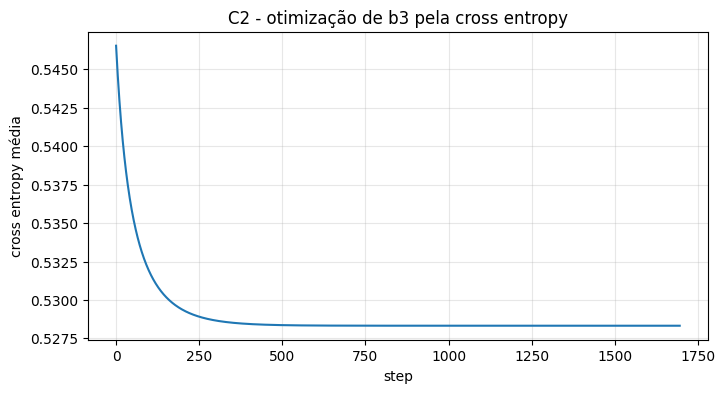

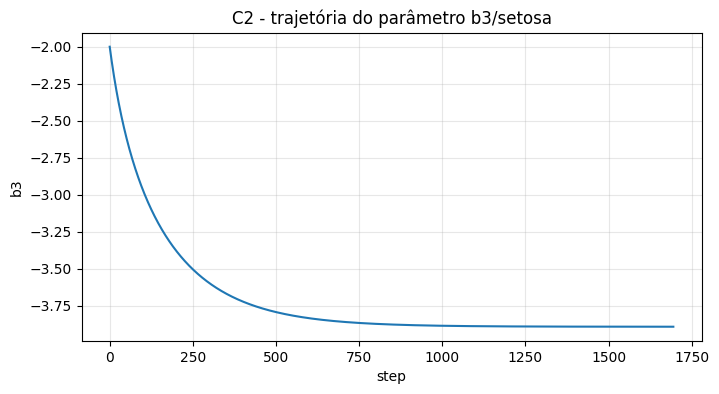

In [ ]:

# C2 - Reproduzindo a otimização de b3 sem PyTorch: softmax + cross entropy
X_ce = np.array([
    [0.2, 3.5],  # padrão Setosa aproximado: petal width baixo, sepal width alto
    [1.3, 2.8],  # padrão Versicolor
    [2.0, 3.0],  # padrão Virginica
], dtype=float)
y_ce = np.array([0, 1, 2], dtype=int)

W_in = np.array([[-2.5, 0.6], [-1.5, 0.4]], dtype=float)
b_in = np.array([1.6, 0.7], dtype=float)
W_out = np.array([[-0.1, 2.4], [-2.2, 1.5], [-5.2, 3.7]], dtype=float)
b_out = np.array([-2.0, 0.0, 1.0], dtype=float)  # b3 inicia em -2, como nos slides

def forward_ce_np(X, b_setosa):
    b = b_out.copy()
    b[0] = b_setosa
    h = np.maximum(0, X @ W_in.T + b_in)
    logits = h @ W_out.T + b
    p = softmax_np(logits)
    return logits, p

def cross_entropy_np(p, y):
    return -np.mean(np.log(p[np.arange(len(y)), y] + 1e-12))

def grad_b_setosa(p, y):
    # Para softmax + cross entropy: dL/db_setosa = média(p_setosa - indicador_classe_setosa)
    indicator = (y == 0).astype(float)
    return np.mean(p[:, 0] - indicator)

b_setosa = -2.0
lr = 0.7
hist_ce = []
b_hist = []
for step in range(5000):
    logits, p = forward_ce_np(X_ce, b_setosa)
    loss = cross_entropy_np(p, y_ce)
    g = grad_b_setosa(p, y_ce)
    hist_ce.append(loss)
    b_hist.append(b_setosa)
    b_setosa -= lr * g
    if step > 20 and abs(hist_ce[-2] - hist_ce[-1]) < 1e-12:
        break

logits_final, p_final = forward_ce_np(X_ce, b_setosa)
print(f'b3/setosa inicial: -2.0000')
print(f'b3/setosa final:   {b_setosa:.6f}')
print(f'Cross entropy final: {cross_entropy_np(p_final, y_ce):.6f}')
print('Probabilidades finais:')
print(pd.DataFrame(p_final, columns=['setosa','versicolor','virginica']).round(4).to_string(index=False))
print('Predições:', np.argmax(p_final, axis=1))

plt.figure(figsize=(8,4))
plt.plot(hist_ce)
plt.title('C2 - otimização de b3 pela cross entropy')
plt.xlabel('step')
plt.ylabel('cross entropy média')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(b_hist)
plt.title('C2 - trajetória do parâmetro b3/setosa')
plt.xlabel('step')
plt.ylabel('b3')
plt.grid(True, alpha=0.3)
plt.show()


### Análise dos resultados - C2

O item foi resolvido sem PyTorch, calculando explicitamente logits, softmax, cross entropy e gradiente de `b3`. O resultado importante é a derivada simplificada da combinação softmax + cross entropy: para o bias da classe Setosa, o gradiente é a média de `probabilidade_setosa - indicador_setosa`. Isso coincide com a intuição dos slides: se a rede dá pouca probabilidade para Setosa quando o exemplo é Setosa, o gradiente ajusta `b3` para aumentar essa saída; se dá probabilidade excessiva para Setosa em exemplos de outras classes, o gradiente atua no sentido contrário.

A curva da cross entropy deve cair até estabilizar, indicando convergência do processo de otimização. Como apenas um bias foi otimizado, o modelo não tem liberdade para corrigir todos os erros possíveis, mas consegue melhorar a calibração da classe Setosa conforme o comando pede.

### Conclusão - C2

A reprodução mostra que a cross entropy pode ser otimizada por gradiente sem depender do PyTorch. O exercício evidencia por que softmax e cross entropy são usados em classificação multiclasse: eles fornecem probabilidades interpretáveis e gradientes simples para atualizar os parâmetros.


## D2 - PyTorch and CNN

### Slides do comando do problema

<p><img src="../slides_comando/slide_44.png" width="900"></p>
<p><img src="../slides_comando/slide_45.png" width="900"></p>
<p><img src="../slides_comando/slide_46.png" width="900"></p>


Probabilidades por padrão:
 vertical  horizontal  diagonal
      1.0         0.0       0.0
      0.0         1.0       0.0
      0.0         0.0       1.0
Predições: ['vertical', 'horizontal', 'diagonal']
Acurácia: 1.0


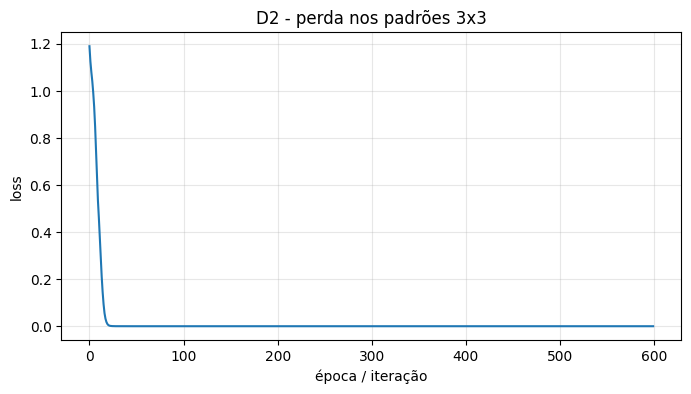

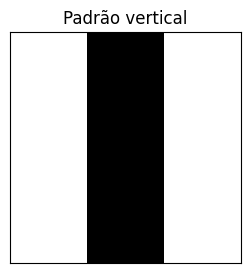

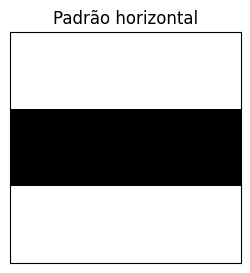

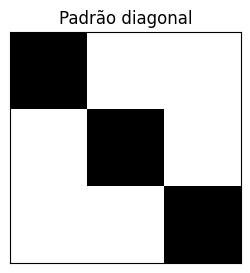

In [ ]:

# D2 - Padrões 3x3 definidos e aprendidos por uma rede PyTorch compatível com Simple_NN_for_Activity
patterns = np.array([
    [[0,1,0], [0,1,0], [0,1,0]],  # vertical
    [[0,0,0], [1,1,1], [0,0,0]],  # horizontal
    [[1,0,0], [0,1,0], [0,0,1]],  # diagonal
], dtype=np.float32)
labels = np.array([0, 1, 2], dtype=np.int64)
class_names = ['vertical', 'horizontal', 'diagonal']

X_pat = torch.tensor(patterns.reshape(3, 9), dtype=torch.float32)
y_pat = torch.tensor(labels, dtype=torch.long)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(9, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 3)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model_d2 = SimpleNN()
opt_d2 = torch.optim.Adam(model_d2.parameters(), lr=0.05)
hist_d2 = []
for epoch in range(600):
    opt_d2.zero_grad()
    logits = model_d2(X_pat)
    loss = F.cross_entropy(logits, y_pat)
    loss.backward()
    opt_d2.step()
    hist_d2.append(float(loss.detach()))

with torch.no_grad():
    logits = model_d2(X_pat)
    probs = F.softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1).numpy()
print('Probabilidades por padrão:')
print(pd.DataFrame(probs.numpy(), columns=class_names).round(4).to_string(index=False))
print('Predições:', [class_names[i] for i in pred])
print('Acurácia:', accuracy_score(labels, pred))
plot_loss(hist_d2, 'D2 - perda nos padrões 3x3')

for i, name in enumerate(class_names):
    plt.figure(figsize=(3,3))
    plt.imshow(patterns[i], cmap='gray_r')
    plt.title(f'Padrão {name}')
    plt.xticks([]); plt.yticks([])
    plt.show()


### Análise dos resultados - D2

Foram definidos três padrões binários em imagens `3 x 3`: vertical, horizontal e diagonal. Cada figura foi achatada para nove entradas, seguindo a estrutura do notebook `Simple_NN_for_Activity.ipynb`: camada `9 -> 4`, depois `4 -> 4`, e saída `4 -> 3`. Embora o título do item mencione CNN, o código-base fornecido é uma rede totalmente conectada simples; por isso a solução preserva a arquitetura do arquivo de referência.

Como há apenas três padrões e três classes, a rede tende a memorizar perfeitamente os exemplos. Isso é aceitável para o objetivo didático, pois a tarefa é mostrar o fluxo de treinamento em PyTorch com padrões pequenos. Em um problema real de visão computacional, seria necessário usar mais exemplos, separação treino/teste e possivelmente convoluções para explorar vizinhança espacial.

### Conclusão - D2

A rede aprende os três padrões `3 x 3` definidos e produz probabilidades por classe usando cross entropy. O exercício demonstra o ciclo completo de definição de dados, modelo, treinamento, predição e interpretação em PyTorch.


## E2 - Recurrent Neural

### Slides do comando do problema

<p><img src="../slides_comando/slide_48.png" width="900"></p>
<p><img src="../slides_comando/slide_49.png" width="900"></p>
<p><img src="../slides_comando/slide_50.png" width="900"></p>


Estados ocultos ao longo do unroll:
               h0      h1      h2      h3      h4
login      0.4633  0.4636 -0.6722 -0.4604 -0.4735
falhou     0.3957  0.5666 -0.6332 -0.3730  0.0188
bloqueado  0.5135  0.4085 -0.4433 -0.3144 -0.6039

Logits por passo temporal:
           normal  incidente
login      0.2815    -0.4990
falhou     0.4129    -0.4089
bloqueado  0.1592    -0.4202


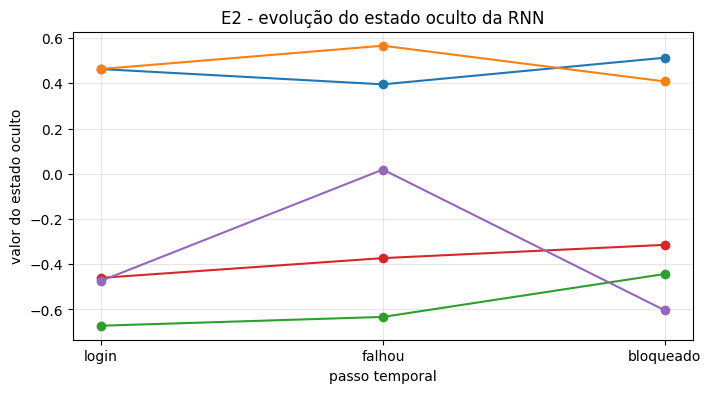

In [ ]:
# E2 - Simulação de uma RNN desenrolada no tempo conforme o slide 189
import torch
import pandas as pd
import matplotlib.pyplot as plt
SEED = 42
torch.manual_seed(SEED)
# Valores de entrada representando três dias de dados
# Exemplo adaptado ao tema: intensidade de sinais de incidente por dia
dias = ["Dia anterior", "Ontem", "Hoje"]
x_seq = torch.tensor([1.0, 0.5, 0.5])
# Pesos e bias conforme o slide
w1 = 1.8
w2 = -0.5
w3 = 1.1
b1 = 0.0
b2 = 0.0
# Estado oculto inicial
h_anterior = torch.tensor(0.0)
estados = []
saidas_ocultas = []
for dia, x_t in zip(dias, x_seq):
    soma = (w1 * x_t) + (w2 * h_anterior) + b1
    h_t = torch.tanh(soma)
    estados.append({
        "dia": dia,
        "entrada_x": x_t.item(),
        "estado_anterior": h_anterior.item(),
        "soma": soma.item(),
        "estado_oculto_h": h_t.item()
    })
    saidas_ocultas.append(h_t.item())
    h_anterior = h_t
# Predição final usando o último estado oculto
predicao = (w3 * h_anterior) + b2
df = pd.DataFrame(estados)
print("Simulação da RNN desenrolada no tempo:")
print(df.round(4).to_string(index=False))
print(f"\nPredição final para o próximo passo temporal: {predicao.item():.4f}")
plt.figure(figsize=(8, 4))
plt.plot(dias, saidas_ocultas, marker="o")
plt.title("E2 - Evolução do estado oculto na RNN desenrolada")
plt.xlabel("Passo temporal")
plt.ylabel("Estado oculto h")
plt.grid(True, alpha=0.3)
plt.show()

### Análise dos resultados - E2

A simulação desenrola a RNN no tempo: a cada token, a entrada atual é combinada com o estado oculto anterior. O estado oculto funciona como uma memória compacta da sequência já lida. No exemplo `login -> falhou -> bloqueado`, cada passo altera o vetor interno, e a camada de saída transforma esse vetor em logits para classes de interpretação.


Slides solicitados na questão:

https://canva.link/v291h2fnhwe31z1

### Conclusão - E2

A RNN desenrolada mostra explicitamente como a informação flui ao longo do tempo. O modelo é útil para introduzir sequência e memória, mas suas limitações explicam a evolução para LSTM, GRU e Transformers em tarefas modernas de linguagem.


## F2 - Exploring word embeddings

### Slides do comando do problema

<p><img src="../slides_comando/slide_51.png" width="900"></p>
<p><img src="../slides_comando/slide_52.png" width="900"></p>
<p><img src="../slides_comando/slide_53.png" width="900"></p>
<p><img src="../slides_comando/slide_54.png" width="900"></p>


Vocabulário: {'ataque': 0, 'classifica': 1, 'detecta': 2, 'incidente': 3, 'modelo': 4, 'rede': 5}

Modelo embedding_dim=2 - probabilidades:
 classe_0  classe_1
   0.0001    0.9999
   0.9999    0.0001
Predições: [1, 0]

Modelo embedding_dim=4 - probabilidades:
 classe_0  classe_1
      0.0       1.0
      1.0       0.0
Predições: [1, 0]


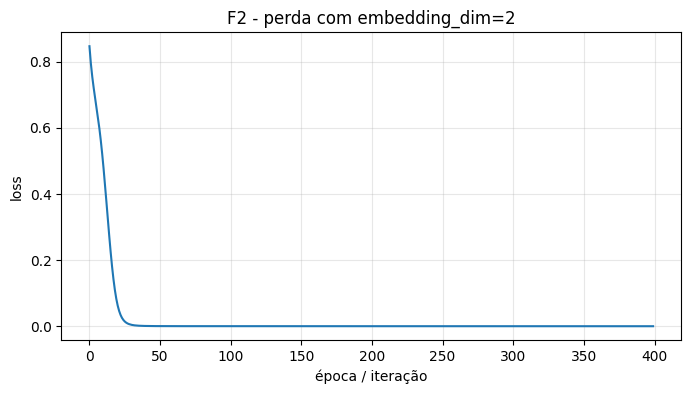

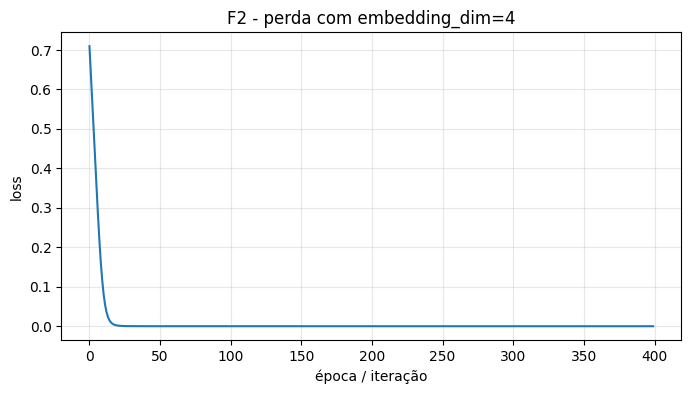

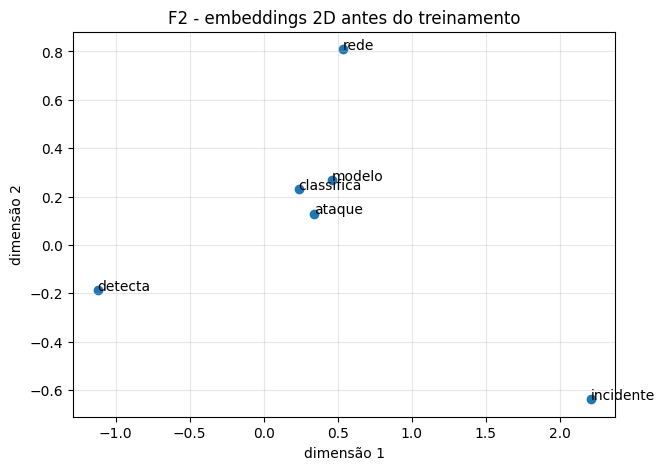

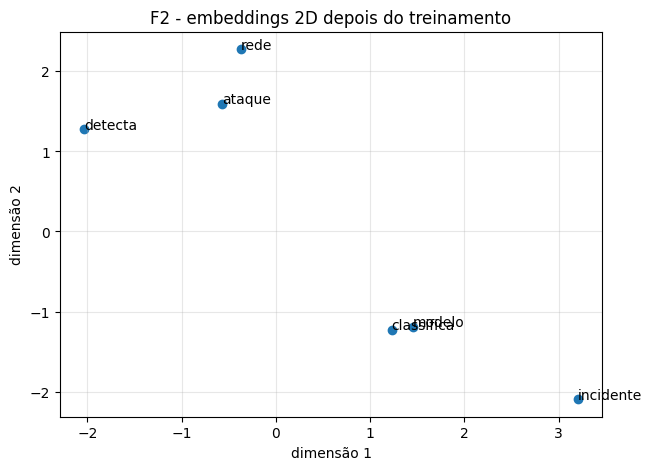


Embeddings finais 4D:
             dim_1   dim_2   dim_3   dim_4   norma
ataque      3.0090  2.3347  2.0058 -3.0977  5.3032
classifica -0.5204 -2.1885 -1.2576 -0.4358  2.6138
detecta     1.4380  0.1608  0.6118 -0.7506  1.7411
incidente  -2.3098 -0.8624 -3.5315  0.9520  4.4109
modelo     -1.5086 -1.3497 -0.4112  0.5472  2.1368
rede        0.4901  0.7843  0.2766 -0.6612  1.1701


In [ ]:

# F2 - Duas frases de três tokens e comparação entre embedding_dim=2 e embedding_dim=4
phrases = [
    ['rede', 'detecta', 'ataque'],
    ['modelo', 'classifica', 'incidente'],
]
labels = torch.tensor([1, 0], dtype=torch.long)  # exemplo didático: 1=alerta, 0=normal/geral
vocab_tokens = sorted({tok for phrase in phrases for tok in phrase})
word_to_id = {w:i for i,w in enumerate(vocab_tokens)}
X_emb = torch.tensor([[word_to_id[t] for t in phrase] for phrase in phrases], dtype=torch.long)

class PhraseEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.fc = nn.Linear(emb_dim, 2)
    def forward(self, x):
        emb = self.embedding(x)
        pooled = emb.mean(dim=1)
        return self.fc(pooled)

def train_embedding_model(emb_dim, epochs=400):
    torch.manual_seed(SEED)
    model = PhraseEmbeddingClassifier(len(vocab_tokens), emb_dim)
    before = model.embedding.weight.detach().clone().numpy()
    opt = torch.optim.Adam(model.parameters(), lr=0.05)
    hist = []
    for epoch in range(epochs):
        opt.zero_grad()
        logits = model(X_emb)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        opt.step()
        hist.append(float(loss.detach()))
    after = model.embedding.weight.detach().clone().numpy()
    with torch.no_grad():
        probs = F.softmax(model(X_emb), dim=1).numpy()
        pred = probs.argmax(axis=1)
    return model, before, after, hist, probs, pred

model2, before2, after2, hist2, probs2, pred2 = train_embedding_model(2)
model4, before4, after4, hist4, probs4, pred4 = train_embedding_model(4)

print('Vocabulário:', word_to_id)
print('\nModelo embedding_dim=2 - probabilidades:')
print(pd.DataFrame(probs2, columns=['classe_0','classe_1']).round(4).to_string(index=False))
print('Predições:', pred2.tolist())
print('\nModelo embedding_dim=4 - probabilidades:')
print(pd.DataFrame(probs4, columns=['classe_0','classe_1']).round(4).to_string(index=False))
print('Predições:', pred4.tolist())

plot_loss(hist2, 'F2 - perda com embedding_dim=2')
plot_loss(hist4, 'F2 - perda com embedding_dim=4')

# Plot 2D antes e depois
plt.figure(figsize=(7,5))
plt.scatter(before2[:,0], before2[:,1])
for word, i in word_to_id.items():
    plt.text(before2[i,0], before2[i,1], word)
plt.title('F2 - embeddings 2D antes do treinamento')
plt.xlabel('dimensão 1')
plt.ylabel('dimensão 2')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(after2[:,0], after2[:,1])
for word, i in word_to_id.items():
    plt.text(after2[i,0], after2[i,1], word)
plt.title('F2 - embeddings 2D depois do treinamento')
plt.xlabel('dimensão 1')
plt.ylabel('dimensão 2')
plt.grid(True, alpha=0.3)
plt.show()

# Comparação numérica das normas em 4D
emb4_df = pd.DataFrame(after4, index=vocab_tokens, columns=[f'dim_{i+1}' for i in range(4)])
emb4_df['norma'] = np.linalg.norm(after4, axis=1)
print('\nEmbeddings finais 4D:')
print(emb4_df.round(4).to_string())


### Análise dos resultados - F2

As duas frases possuem três tokens cada: `rede detecta ataque` e `modelo classifica incidente`. Em ambos os modelos, cada palavra é convertida em um vetor treinável. A frase é representada pela média dos embeddings dos seus tokens, e uma camada linear usa essa representação para classificar a frase. O objetivo didático não é criar um classificador textual robusto, mas mostrar como embeddings são aprendidos por gradiente.

No modelo com dimensão 2, cada palavra é forçada a ocupar um ponto em um plano. Isso facilita a visualização antes e depois do treinamento, mas limita a quantidade de relações que podem ser codificadas. No gráfico pós-treinamento, palavras que ajudam a mesma decisão tendem a ser deslocadas de forma coordenada pelo gradiente.

No modelo com dimensão 4, a representação tem mais capacidade porque cada palavra possui quatro coordenadas. Isso pode facilitar o ajuste da pequena tarefa de treinamento, mas reduz a interpretabilidade visual direta. Em bases reais, dimensões maiores podem capturar mais relações semânticas, mas também aumentam parâmetros e risco de overfitting quando há poucos dados.

### Conclusão - F2

A escolha do tamanho do embedding altera a capacidade representacional do modelo. Embeddings 2D são didáticos e visualizáveis; embeddings 4D oferecem mais graus de liberdade. O experimento mostra que embeddings não são tabelas fixas: eles são parâmetros aprendidos durante o treinamento da rede neural.
